PROYECTO - <h2>Análisis de factores de éxito en el mercado de videojuegos<h2>

La tienda online Ice, dedicada a la venta de videojuegos a nivel mundial, cuenta con información proveniente de fuentes abiertas que incluye reseñas de usuarios y expertos, géneros, plataformas como Xbox y PlayStation, así como datos históricos de ventas. Sin embargo, la empresa enfrenta una problemática clave: no dispone de un análisis estructurado que le permita comprender qué factores influyen realmente en el éxito comercial de un videojuego. Sin esta información, la planificación de campañas publicitarias y la selección de títulos prometedores para el próximo año se basan más en intuición que en evidencia.

Como analista de datos, el desafío consiste en identificar patrones que permitan determinar qué factores influyen en el éxito de un videojuego, considerando variables como la plataforma, el género, las calificaciones de usuarios y críticos, y el comportamiento histórico de ventas. Con datos disponibles hasta 2016 y situándonos en diciembre de ese mismo año, el objetivo es analizar esta información de manera integral mediante métodos estadísticos y exploración de datos para detectar los elementos clave que impactan en la popularidad y rentabilidad de los títulos. Este análisis permitirá anticipar tendencias del mercado, identificar proyectos con mayor potencial y diseñar campañas publicitarias más estratégicas y efectivas para el año 2017.

<h2>1.Inicialización - Cargar librerias y archivo de datos<h2>

In [1]:
#Cargar todas las librerías
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
from scipy import stats

In [2]:
#Cargar archivo de datos
games= pd.read_csv('/datasets/games.csv', sep=",")




<h2>Preparar los datos para el análisis<h2>

El Objetivo es identificar los tipos de datos e información contenida en cada DataFrame.

In [ ]:
# Imprimir la información general/resumida sobre el DataFrame "games"
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
# Imprime una muestra de los datos
games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [5]:
#muestra información de estadísticas descriptivas
games.describe(include='all')

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
count,16713,16715,16446.000000,16713,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000,10014,9949
unique,11559,31,NaN,12,NaN,NaN,NaN,NaN,NaN,96,8
top,Need for Speed: Most Wanted,PS2,NaN,Action,NaN,NaN,NaN,NaN,NaN,tbd,E
freq,12,2161,NaN,3369,NaN,NaN,NaN,NaN,NaN,2424,3990
mean,NaN,NaN,2006.484616,NaN,0.263377,0.145060,0.077617,0.047342,68.967679,NaN,NaN
std,NaN,NaN,5.877050,NaN,0.813604,0.503339,0.308853,0.186731,13.938165,NaN,NaN
min,NaN,NaN,1980.000000,NaN,0.000000,0.000000,0.000000,0.000000,13.000000,NaN,NaN
25%,NaN,NaN,2003.000000,NaN,0.000000,0.000000,0.000000,0.000000,60.000000,NaN,NaN
50%,NaN,NaN,2007.000000,NaN,0.080000,0.020000,0.000000,0.010000,71.000000,NaN,NaN
75%,NaN,NaN,2010.000000,NaN,0.240000,0.110000,0.040000,0.030000,79.000000,NaN,NaN


Observaciones iniciales: 
El conjunto de datos cuenta con 16,715 registros y presenta valores ausentes en algunas columnas como "name", "year_of_release", "genre", "critic_score", "user_score" y "rating". La columna "year_of_release" está en formato float y debe ser tipo int ya que los años son valores discretos, también la columna "user_score" está como object (texto) y debe ser numérica.

## Corregirmos los datos

In [6]:
#Reemplazamos nombres de columnas a minusculas:
games.columns = games.columns.str.lower()
print(f"Nuevos nombres de columnas: {list(games.columns)}")

Nuevos nombres de columnas: ['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


In [ ]:
# Cambiamos el tipo de dato en la columna "user_score" de object a float

# Primero reemplazamos 'TBD' con NaN para poder convertir a numérico
games['user_score'] = games['user_score'].replace('tbd', np.nan)
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

#verificamos el cambio
print(games.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB
None


-Reemplazamos los datos"tbt" de la columna "user_score", de object a float porque  necesitamos datos numéricos para poder realizar cálculos.
-La columna "year_of_release" posteriormente la cambiaremos a int, una vez tratados los valores nulos.

In [8]:
#Contamos los duplicados
print("Cantidad de filas duplicadas:")
duplicados = games.duplicated().sum()
print(duplicados)

Cantidad de filas duplicadas:
0


In [ ]:
#Tratamos Valores Ausentes
# Analizamos valores nulos
print("Valores nulos por columna:")
nulls = games.isna().sum()
print(nulls)

Valores nulos por columna:
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


In [ ]:
#eliminamos los valores ausentes de name y genre
games = games.dropna(subset=['name', 'genre'])
#eliminamos los valores ausentes de year_of_release
games = games.dropna(subset=['year_of_release'])

In [11]:
#sustituimos los valores ausentes de la columna rating con 'Unknown'
games['rating'].fillna('Unknown', inplace=True)
# verificamos
print("Verificamos nuevamente valores nulos por columna:")
nulls = games.isna().sum()
print(nulls)
games.info()

Verificamos nuevamente valores nulos por columna:
name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating                0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating 

<h3>Conclusiones<h3>

En esta parte tratamos los valores ausentes de la siguiente manera: 
-Se eliminaron los registros sin name o genre, ya que solo son 2 filas y carecen de utilidad.  
-También aquellos ausentes de la columna year_of_release los eliminamos ya que, por ser un dato esencial para el análisis, al no contar con esta información, no nos sirve. 
-Los valores nulos en la columna critic_score y user_score probablemente se deben a que varios juegos, en especial los más antiguos o menos populares, no obtuvieron suficientes reseñas para calcular una puntuación confiable. Por esta razón se conservaran como nulos, con el fin de conservar la integridad del conjunto de datos y evitar sesgos o distorsiones en los análisis posteriores.
-Los valores ausentes en rating se reemplazaron por la categoría “Unknown”, permitiendo mantener la coherencia en los datos y nos facilitara su uso en operaciones futuras. 

<h3>2.2 Cálculo de las ventas totales<h3>

In [12]:
#nueva columna para ventas totales
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
print(games.head())


                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score   rating  \
0     28.96      3.77         8.45          76.0         8.0        E   
1      3.58      6.81         0.77           NaN         NaN  Unknown   
2     12.76      3.79         3.29          82.0         8.3        E   
3     10.93      3.28         2.95          80.0         8.0        E   
4      8.89     10.22         1.00           NaN         NaN  Unknown   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3     

Adicional se crea una nueva columna con el cálculo de las ventas totales de todas las regiones.

<h2>3.Análisis de los datos<h2>

<h3>3.1 Analizamos juegos por año<h3>

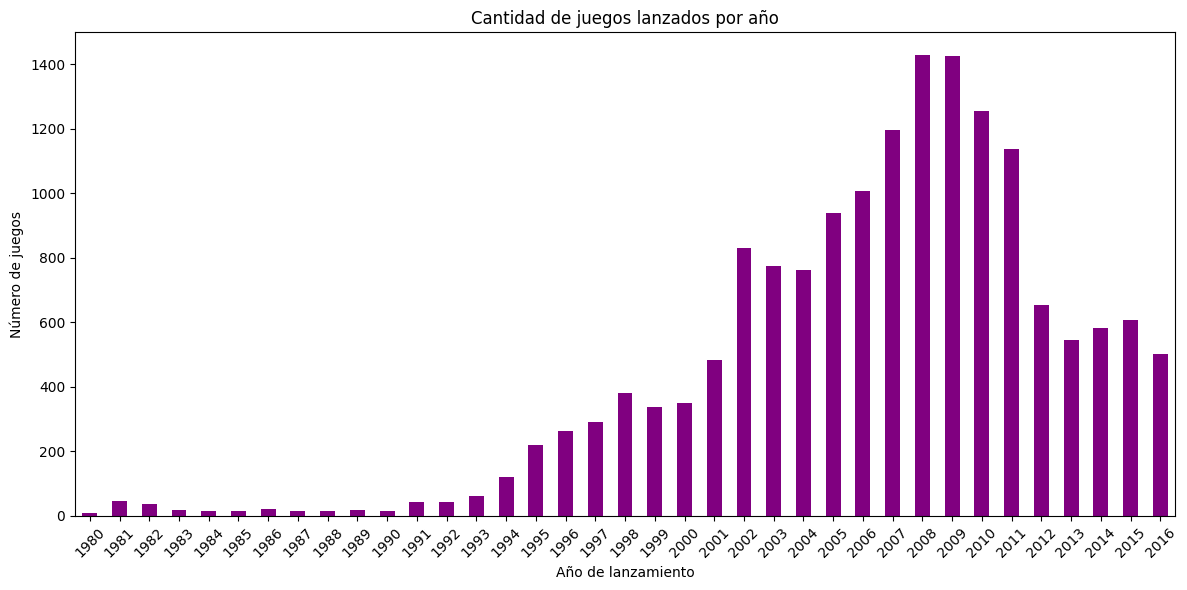

In [ ]:
#convertimos 'year_of_release' a int
games['year_of_release'] = games['year_of_release'].astype(int)

#agrupamos juegos por año
games_years= games.groupby('year_of_release')['name'].count()

# Mostramos Gráfico de barras
plt.figure(figsize=(12, 6))
games_years.plot(kind='bar',color='purple')
plt.title('Cantidad de juegos lanzados por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<h3>3.2 Analizamos Ventas por plataforma<h3>

OBSERVACIONES: 

Los datos de inicio de los 80's hasta el año 1995 no son muy representativos ya que existen pocos juegos y tenemos pocos datos.
Tenemos datos más significativos entre el año 2000 y 2011.
Después del 2012 aún tenemos datos útiles, aunque debemos considerar que la base puede no incluir todos los lanzamientos digitales o independientes, ya que la información supone que estos juegos aumentaron a partir del 2010.


Plataformas lideres: platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
Name: total_sales, dtype: float64


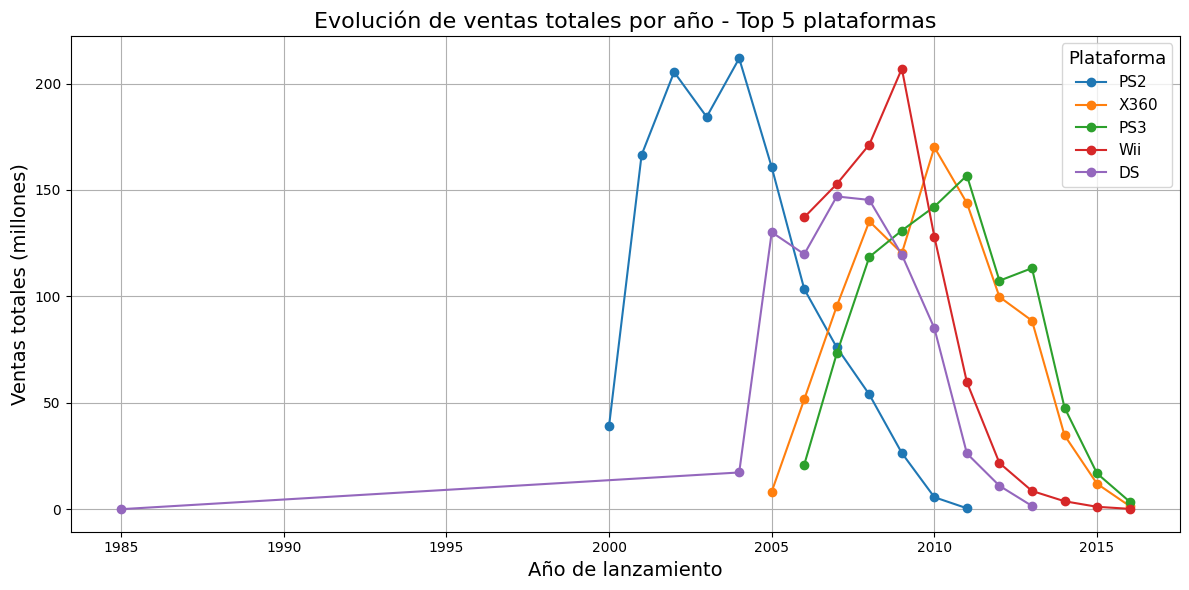

In [14]:
#agrupamos ventas por plataforma (Plataformas lideres)
sales_plataform= games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
top5_platforms = sales_plataform.head(5)
print(f"Plataformas lideres: {top5_platforms}")

# Filtro de datos y grafica de ventas por año para cada plataforma
plt.figure(figsize=(12, 6))

for platform in top5_platforms.index:
    platform_data = (
        games[games['platform'] == platform]
        .groupby('year_of_release')['total_sales']
        .sum()
        .sort_index()
    )
    plt.plot(platform_data.index, platform_data.values, marker='o', label=platform)

# Personalizar gráfico
plt.title('Evolución de ventas totales por año - Top 5 plataformas', fontsize=16)
plt.xlabel('Año de lanzamiento', fontsize=14)
plt.ylabel('Ventas totales (millones)', fontsize=14)
plt.legend(title='Plataforma',title_fontsize=13, fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

OBSERVACIONES: 

Las 5 plataformas mostradas en este gráfico (PS2, X360, PS3, Wii y DS), fueron las mas populares, pero ya no tienen ventas significativas al final del período registrado (aprox. 2016).
El gráfico muestra que tardan entre 3 y 5 años desde su lanzamiento en alcanzar su pico máximo de ventas anuales y una vez que una plataforma alcanza su punto clave, su declive hasta tener ventas casi nulas toma generalmente entre 5 y 9 años.
Podemos concluir que el ciclo de vida de ventas completo de una plataforma exitosa (desde su lanzamiento hasta que sus ventas anuales son casi nulas) dura aproximadamente entre 9 y 12 años.


<h3>3.3 Determina período para análisis<h3>  

In [15]:
# Determinar el período Análisis 
print("Análisis para determinar período relevante:")

# 1. Ver cuándo aparecieron plataformas actuales
top5_platforms = ['PS4', 'XOne', '3DS', 'WiiU', 'PC']
for plataforma in top5_platforms:
    if plataforma in games['platform'].values:
        primer_año = games[games['platform'] == plataforma]['year_of_release'].min()
        print(f"{plataforma}: apareció en {primer_año}")
# 2. Muestra datos por año
juegos_por_año = games.groupby('year_of_release').size()
print("\nJuegos lanzados por año (últimos años):")
print(juegos_por_año.tail(10))

Análisis para determinar período relevante:
PS4: apareció en 2013
XOne: apareció en 2013
3DS: apareció en 2011
WiiU: apareció en 2012
PC: apareció en 1985

Juegos lanzados por año (últimos años):
year_of_release
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
dtype: int64




OBSERVACIONES: 

Para construir el modelo para 2017, El período relevante de análisis debe abarcar desde 2013 hasta 2016, ya que contiene información relevante para predecir tendencias de 2017. Tambíen tenemos todas las plataformas modernas disponibles y datos actualizados sobre el comportamiento del mercado.



<h3>3.4 Analizar tendencias de los últimos años<h3>

In [16]:
# Filtrar datos para el período relevante
games_filtered = games[games['year_of_release'].between(2013, 2016)]

# Verificar cuántos juegos tienes
print(f"Juegos en período 2013-2016: {len(games_filtered)}")
print(f"Distribución por año:")
print(games_filtered['year_of_release'].value_counts().sort_index())
print()

# Analizar tendencias de los últimos años (2013-2016)
años_recientes = [2013, 2014, 2015, 2016]

print("Análisis de tendencias 2013-2016, plataformas:")
for platform in ['PS4', 'XOne', '3DS', 'WiiU', 'PC']:
    if platform in games['platform'].values:
        ventas_recientes = games[
            (games['platform'] == platform) & 
            (games['year_of_release'].isin(años_recientes))
        ].groupby('year_of_release')['total_sales'].sum()
        
        if len(ventas_recientes) >= 2:
            tendencia = "CRECE" if ventas_recientes.iloc[-1] > ventas_recientes.iloc[0] else "SE REDUCE"
            print(f"{platform}: {tendencia}")
            print(f"  2013: {ventas_recientes.get(2013, 0):.1f}M")
            print(f"  2014: {ventas_recientes.get(2014, 0):.1f}M")
            print(f"  2015: {ventas_recientes.get(2015, 0):.1f}M") 
            print(f"  2016: {ventas_recientes.get(2016, 0):.1f}M")

Juegos en período 2013-2016: 2233
Distribución por año:
2013    544
2014    581
2015    606
2016    502
Name: year_of_release, dtype: int64

Análisis de tendencias 2013-2016, plataformas:
PS4: CRECE
  2013: 26.0M
  2014: 100.0M
  2015: 118.9M
  2016: 69.3M
XOne: CRECE
  2013: 19.0M
  2014: 54.1M
  2015: 60.1M
  2016: 26.2M
3DS: SE REDUCE
  2013: 56.6M
  2014: 43.8M
  2015: 27.8M
  2016: 15.1M
WiiU: SE REDUCE
  2013: 21.6M
  2014: 22.0M
  2015: 16.4M
  2016: 4.6M
PC: SE REDUCE
  2013: 12.4M
  2014: 13.3M
  2015: 8.5M
  2016: 5.2M


OBSERVACIONES: 

Basándome en la información de las plataformas lideres en ventas, se observa que 3DS, WiiU y PC reducen sus ventas durante ese periodo, podríamos ver que se acercan al final de su ciclo de vida o que el mercado está migrando hacia otros formatos/plataformas. Aunque PS4 y Xbox One aún mantienen una base sólida de usuarios, también comienzan a reducirse. En cambio, el mercado se desplaza hacia plataformas digitales, PC y móviles, que presentan un crecimiento sostenido y mayor rentabilidad. Por ello, las plataformas potencialmente rentables y más prometedoras en ese periodo son PS4, Xbox One y las digitales emergentes.

<h3> 3.5 Identificamos plataformas rentables<h3>


In [17]:
# Identificar plataformas rentables para 2017
print("Plataformas potencialmente rentables para 2017:")

# 1. Plataformas con ventas fuertes en 2016
ventas_2016 = games[games['year_of_release'] == 2016].groupby('platform')['total_sales'].sum().sort_values(ascending=False)


print("\nTop plataformas en 2016:")
print()
print(ventas_2016.head())


# 2. Plataformas con crecimiento 2015-2016 (versión mejorada)
print("\nAnálisis de crecimiento 2015-2016:")
print()

for platform in ventas_2016.head().index:
    # Ventas totales del año 2015 para esta plataforma
    ventas_2015 = games[
        (games['platform'] == platform) & 
        (games['year_of_release'] == 2015)
    ]['total_sales'].sum()

    # Ventas totales del año 2016 para esta plataforma
    ventas_2016_plat = ventas_2016[platform]

    if ventas_2015 > 0:
        # Calcula el porcentaje de crecimiento
        crecimiento = (ventas_2016_plat - ventas_2015) / ventas_2015 * 100
        
        # Determina si creció o disminuyó
        if crecimiento > 0:
            tendencia = "aumentó"
        else:
            tendencia = "disminuyó"

        # Imprime el resultado con texto descriptivo
        print(f"{platform}: {tendencia} {abs(crecimiento):.2f}% respecto a 2015")
    else:
        print(f"{platform}: No hubo ventas registradas en 2015")



Plataformas potencialmente rentables para 2017:

Top plataformas en 2016:

platform
PS4     69.25
XOne    26.15
3DS     15.14
PC       5.25
WiiU     4.60
Name: total_sales, dtype: float64

Análisis de crecimiento 2015-2016:

PS4: disminuyó 41.76% respecto a 2015
XOne: disminuyó 56.52% respecto a 2015
3DS: disminuyó 45.50% respecto a 2015
PC: disminuyó 38.38% respecto a 2015
WiiU: disminuyó 71.87% respecto a 2015


OBSERVACIONES: 

Las plataformas disminuyen entre 2015 y 2016, pero aun así PS4 y Xbox One siguen siendo las más rentables por su alto volumen de ventas. La opción más sólida para invertir en 2017 es PS4, porque a pesar de la disminución, mantiene una clara ventaja sobre las demás. 3DS conserva un mercado estable, mientras que WiiU y PC muestran menor potencial de crecimiento.

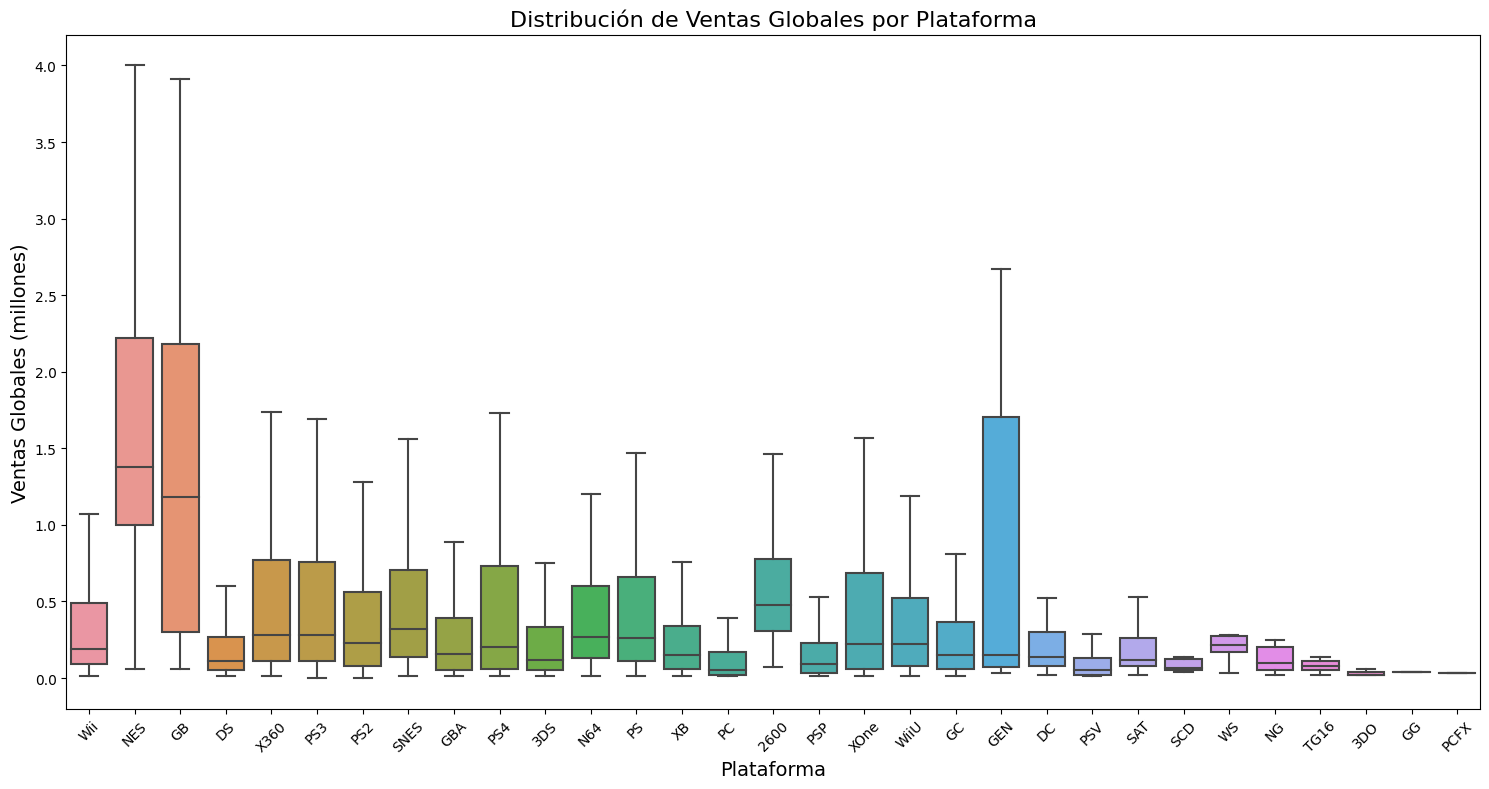

In [19]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(15, 8))

# Crear el boxplot
sns.boxplot(data=games, x='platform', y='total_sales', showfliers = False) # <- Nuevo parametro

# Personalizar el gráfico
plt.title('Distribución de Ventas Globales por Plataforma', fontsize=16)
plt.xlabel('Plataforma', fontsize=14)
plt.ylabel('Ventas Globales (millones)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

OBSERVACIONES: 

Se observa que existen diferencias notables en las ventas globales entre plataformas, con algunas consolas como Wii, NES y GB destacando por sus mayores ventas promedio y ademas tiene los titulos más exitosos. No obstante, la mayoría de las plataformas registran ventas moderadas, lo que indica que el éxito depende de unos pocos juegos populares. En el año 2016, las plataformas más rentables fueron PS4, Xbox One y 3DS, aunque todas experimentaron una fuerte disminución en sus ventas respecto a 2015, lo que sugiere un declive general del mercado y el final del ciclo de varias generaciones de consolas.

<h3>3.6 Calculamos estadísticas descriptivas<h3>

In [20]:
# Complementar con estadísticas descriptivas
print("Estadísticas de ventas por plataforma:")
stats_by_platform = games.groupby('platform')['total_sales'].agg(['count', 'mean', 'median', 'std']).round(2)
print(stats_by_platform.sort_values('median', ascending=False).head(10))

Estadísticas de ventas por plataforma:
          count  mean  median   std
platform                           
NES          98  2.56    1.38  5.11
GB           97  2.62    1.18  5.39
2600        116  0.75    0.48  0.96
SNES        239  0.84    0.32  1.87
X360       1232  0.78    0.28  1.63
PS3        1306  0.71    0.28  1.40
N64         316  0.69    0.27  1.32
PS         1190  0.61    0.26  1.06
PS2        2127  0.58    0.23  1.14
XOne        247  0.65    0.22  1.04


<h3>3.7 Identificarmos patrones<h3>

In [21]:
# Analizar valores atípicos por plataforma
print("\nJuegos con mayores ventas por plataforma:")
for platform in games['platform'].value_counts().head(5).index:
    platform_data = games[games['platform'] == platform]
    q3 = platform_data['total_sales'].quantile(0.75)
    iqr = q3 - platform_data['total_sales'].quantile(0.25)
    outlier_threshold = q3 + 1.5 * iqr
    
    outliers = platform_data[platform_data['total_sales'] > outlier_threshold]
    if len(outliers) > 0:
        print(f"\n{platform}:")
        print(outliers[['name', 'total_sales']].sort_values('total_sales', ascending=False).head(3))


Juegos con mayores ventas por plataforma:

PS2:
                             name  total_sales
17  Grand Theft Auto: San Andreas        20.81
24    Grand Theft Auto: Vice City        16.15
28         Gran Turismo 3: A-Spec        14.97

DS:
                     name  total_sales
6   New Super Mario Bros.        29.80
10             Nintendogs        24.67
11          Mario Kart DS        23.21

PS3:
                              name  total_sales
16              Grand Theft Auto V        21.05
34      Call of Duty: Black Ops II        13.79
37  Call of Duty: Modern Warfare 3        13.33

Wii:
                name  total_sales
0         Wii Sports        82.54
2     Mario Kart Wii        35.52
3  Wii Sports Resort        32.77

X360:
                              name  total_sales
14              Kinect Adventures!        21.82
23              Grand Theft Auto V        16.27
29  Call of Duty: Modern Warfare 3        14.73


OBSERVACIONES: 

Las plataformas más antiguas como NES y GB presentan mayores ventas promedio por juego, mientras que consolas más modernas como PS2, PS3 y X360 tienen ventas más uniformes pero menores en promedio. Sin embargo, los datos muestran que el éxito global depende de títulos excepcionales. Por ejemplo, Wii Sports y Mario Kart Wii impulsaron el dominio de Wii. En DS, sagas como Mario Kart y Nintendogs lograron ventas superiores a 20 millones. En PS2, PS3 y X360, franquicias como Grand Theft Auto y Call of Duty fueron las más exitosas. En conjunto, pocas franquicias emblemáticas concentraron la mayor parte del éxito comercial.

<h3>3.8 Analizamos reseñas de usuarios y profesionales<h3>

Análisis para PS4:
Total de juegos: 392
Juegos con critic_score: 252
Juegos con user_score: 257
Juegos con ambas reseñas: 249


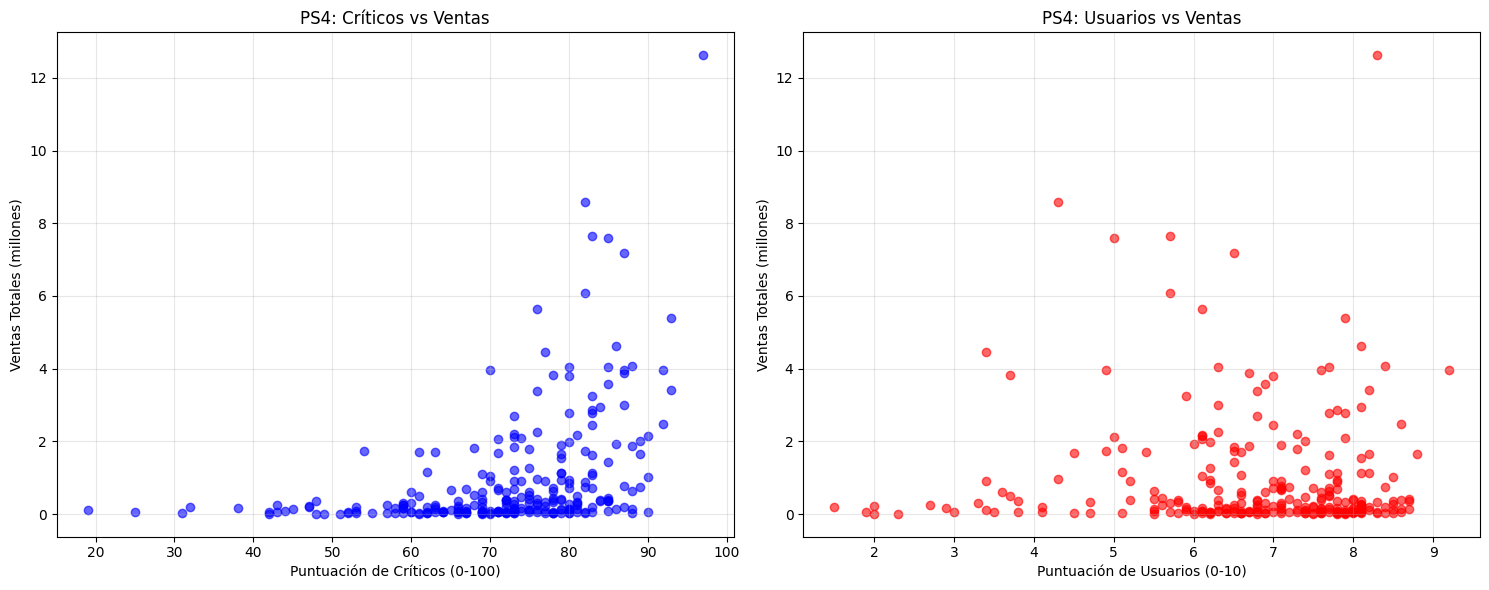


Correlación Críticos-Ventas:
Coeficiente de correlación: 0.407
P-value: 0.000
Sificativa: Sí

Correlación Usuarios-Ventas:
Coeficiente de correlación: -0.032
P-value: 0.610
Significativa: No


In [22]:
# Elegir una plataforma popular con suficientes datos de reseñas
platform_choice = 'PS4'  # o 'XOne', 'PS3', 'X360'

# Filtrar datos para la plataforma elegida
platform_data = games[games['platform'] == platform_choice].copy()

# Verificar cuántos juegos tienen reseñas
print(f"Análisis para {platform_choice}:")
print(f"Total de juegos: {len(platform_data)}")
print(f"Juegos con critic_score: {platform_data['critic_score'].notna().sum()}")
print(f"Juegos con user_score: {platform_data['user_score'].notna().sum()}")
print(f"Juegos con ambas reseñas: {platform_data[['critic_score', 'user_score']].notna().all(axis=1).sum()}")

#Crear gráficos de dispersión

# Crear subplots para ambos tipos de reseñas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Critic Score vs Ventas
platform_critics = platform_data.dropna(subset=['critic_score', 'total_sales'])
ax1.scatter(platform_critics['critic_score'], platform_critics['total_sales'], alpha=0.6, color='blue')
ax1.set_xlabel('Puntuación de Críticos (0-100)')
ax1.set_ylabel('Ventas Totales (millones)')
ax1.set_title(f'{platform_choice}: Críticos vs Ventas')
ax1.grid(True, alpha=0.3)

# Gráfico 2: User Score vs Ventas
platform_users = platform_data.dropna(subset=['user_score', 'total_sales'])
ax2.scatter(platform_users['user_score'], platform_users['total_sales'], alpha=0.6, color='red')
ax2.set_xlabel('Puntuación de Usuarios (0-10)')
ax2.set_ylabel('Ventas Totales (millones)')
ax2.set_title(f'{platform_choice}: Usuarios vs Ventas')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular correlaciones
from scipy.stats import pearsonr

# Correlación con critic_score
if len(platform_critics) > 1:
    corr_critics, p_value_critics = pearsonr(platform_critics['critic_score'], platform_critics['total_sales'])
    print(f"\nCorrelación Críticos-Ventas:")
    print(f"Coeficiente de correlación: {corr_critics:.3f}")
    print(f"P-value: {p_value_critics:.3f}")
    print(f"Sificativa: {'Sí' if p_value_critics < 0.05 else 'No'}")
else:
    print("\nNo hay suficientes datos para calcular la correlación Usuarios-Ventas.")
# Correlación con user_score
if len(platform_users) > 1:
    corr_users, p_value_users = pearsonr(platform_users['user_score'], platform_users['total_sales'])
    print(f"\nCorrelación Usuarios-Ventas:")
    print(f"Coeficiente de correlación: {corr_users:.3f}")
    print(f"P-value: {p_value_users:.3f}")
    print(f"Significativa: {'Sí' if p_value_users < 0.05 else 'No'}")
else:
    print("\nNo hay suficientes datos para calcular la correlación Usuarios-Ventas.")

OBSERVACIONES: 

Las opiniones de los críticos si influyen más en las ventas que las opiniones de los jugadores. En los juegos de PS4, se encontró que cuando los críticos ponen mejores calificaciones, esos juegos tienden a vender más. Es decir, hay una relación clara entre buenas reseñas de críticos y mayores ventas.
En cambio, las calificaciones que dan los jugadores no parecen tener mucho efecto en las ventas: un juego puede tener buenas o malas opiniones de los usuarios, y eso no cambia mucho cuánto se vende.

<h3>3.9 Identificamos juegos multiplataforma<h3>

Top 10 juegos multiplataforma por ventas totales:
                                num_platforms  total_sales
name                                                      
Grand Theft Auto V                          5        56.58
Super Mario Bros.                           2        45.31
Tetris                                      2        35.84
Call of Duty: Modern Warfare 3              4        30.60
Call of Duty: Black Ops II                  4        29.40
Call of Duty: Black Ops                     4        29.20
Call of Duty: Ghosts                        6        27.39
Super Mario World                           2        26.09
Call of Duty: Black Ops 3                   5        25.67
Call of Duty: Modern Warfare 2              3        24.97

Juegos seleccionados para análisis:
- Grand Theft Auto V: 5 plataformas (PS3, X360, PS4, XOne, PC)

- Super Mario Bros.: 2 plataformas (NES, GB)

- Tetris: 2 plataformas (GB, NES)

- Call of Duty: Modern Warfare 3: 4 plataformas (X360, PS3, 

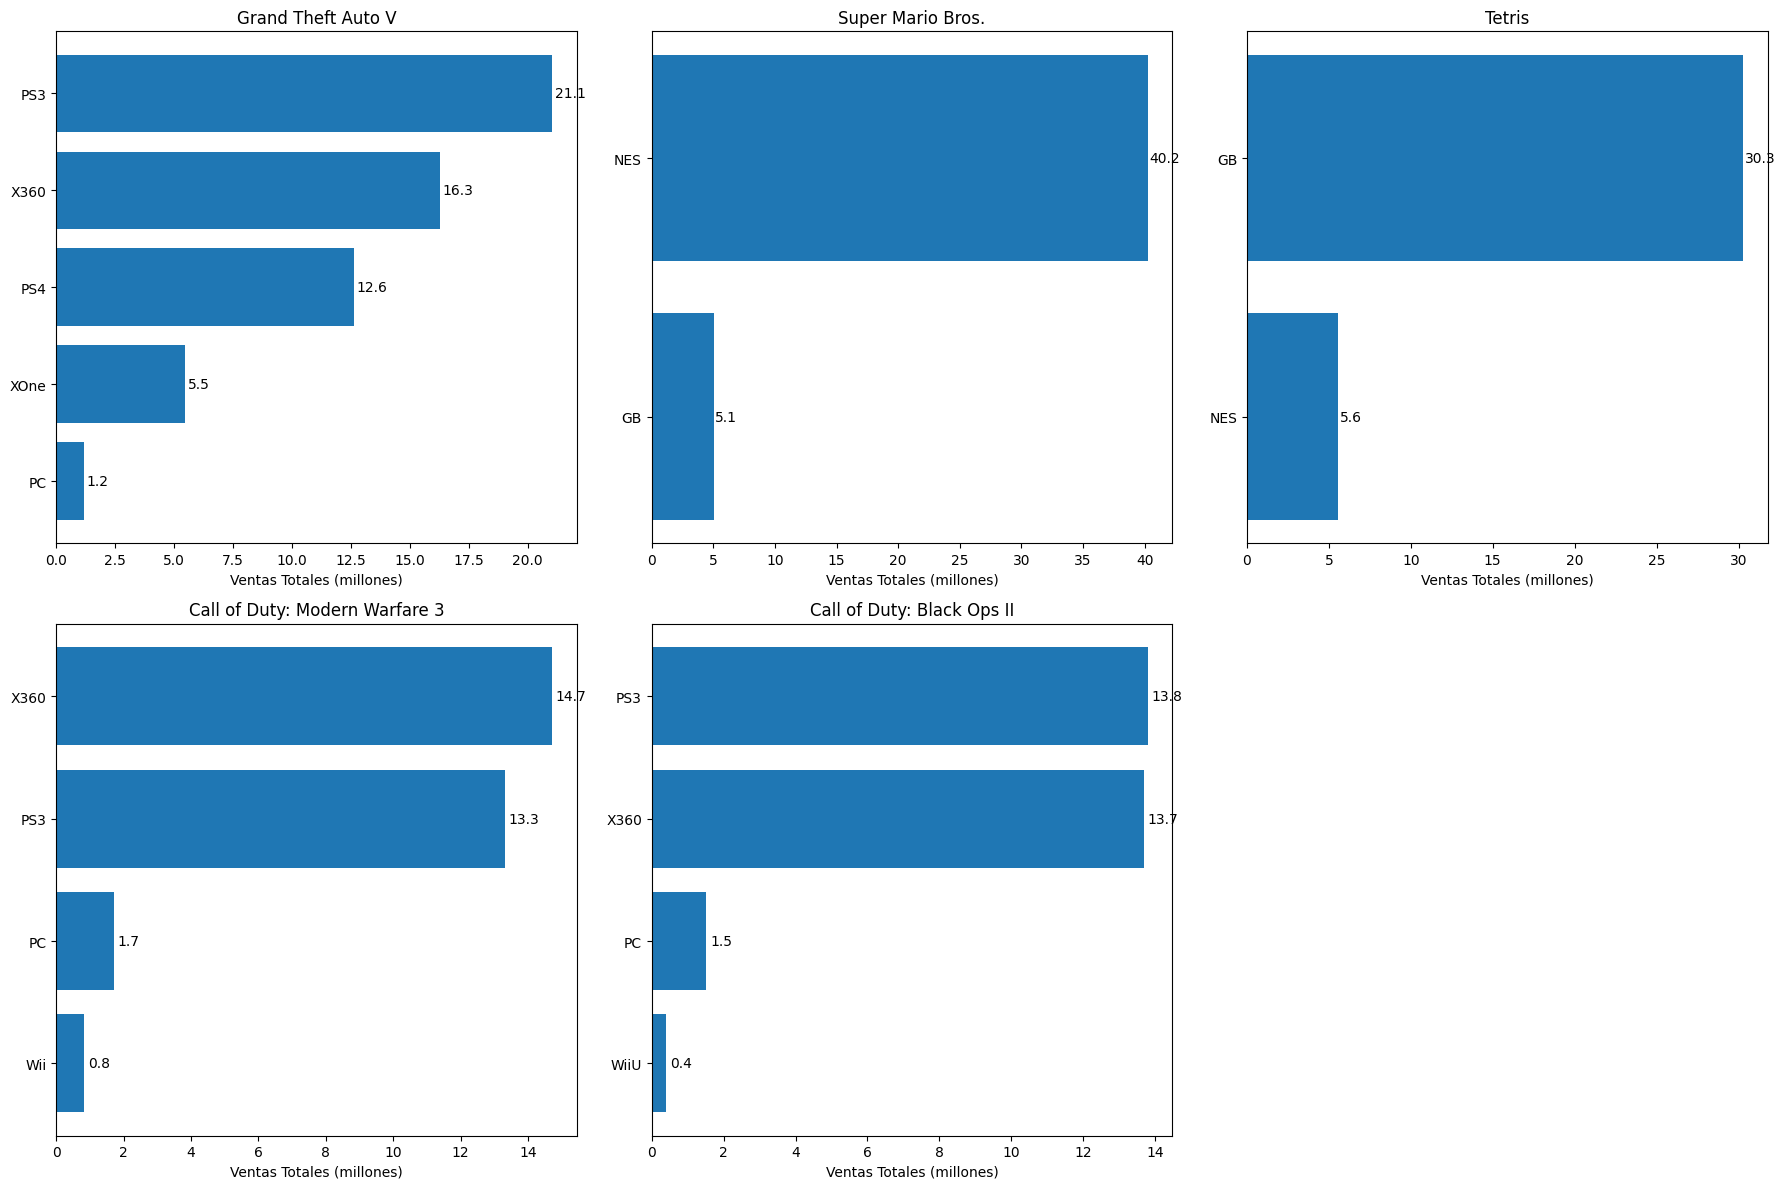


Comparación detallada de los top 3 juegos multiplataforma:


,game,platform,total_sales,critic_score,user_score,year_of_release
0,Grand Theft Auto V,PS3,21.05,97.0,8.2,2013
1,Grand Theft Auto V,X360,16.27,97.0,8.1,2013
2,Grand Theft Auto V,PS4,12.62,97.0,8.3,2014
3,Grand Theft Auto V,XOne,5.47,97.0,7.9,2014
4,Grand Theft Auto V,PC,1.17,96.0,7.9,2015
5,Super Mario Bros.,NES,40.24,NaN,NaN,1985
6,Super Mario Bros.,GB,5.07,NaN,NaN,1999
7,Tetris,GB,30.26,NaN,NaN,1989
8,Tetris,NES,5.58,NaN,NaN,1988


In [23]:
# Encontrar juegos que están en múltiples plataformas
games_multiplatform = games.groupby('name').agg({
    'platform': 'count',
    'total_sales': 'sum'
}).rename(columns={'platform': 'num_platforms'})

# Filtrar juegos que están en al menos 2 plataformas
popular_multiplatform = games_multiplatform[games_multiplatform['num_platforms'] >= 2]
popular_multiplatform = popular_multiplatform.sort_values('total_sales', ascending=False)

print("Top 10 juegos multiplataforma por ventas totales:")
print(popular_multiplatform.head(10))


# Elegir algunos juegos exitosos para análisis detallado
top_games = popular_multiplatform.head(5).index.tolist()


print()
print("Juegos seleccionados para análisis:")
for game in top_games:
    platforms = games[games['name'] == game]['platform'].unique()
    print(f"- {game}: {len(platforms)} plataformas ({', '.join(platforms)})")
    print()
# Crear gráfico de barras comparativo
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, game_name in enumerate(top_games):
    if i < 6:  # Limitar a 6 juegos para el layout
        game_data = games[games['name'] == game_name].copy()
        
        # Ordenar por ventas totales
        game_data = game_data.sort_values('total_sales', ascending=True)
        
        axes[i].barh(game_data['platform'], game_data['total_sales'])
        axes[i].set_title(f'{game_name}', fontsize=12)
        axes[i].set_xlabel('Ventas Totales (millones)')
        
        # Agregar valores en las barras
        for j, (platform, sales) in enumerate(zip(game_data['platform'], game_data['total_sales'])):
            axes[i].text(sales + 0.1, j, f'{sales:.1f}', va='center')

# Ocultar subplots vacíos si hay menos de 6 juegos
for i in range(len(top_games), 6):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()
# Crear tabla comparativa detallada
comparison_data = []

for game_name in top_games[:3]:  # Analizar top 3 juegos
    game_platforms = games[games['name'] == game_name].copy()

    for _, row in game_platforms.iterrows():
        comparison_data.append({
            'game': game_name,
            'platform': row['platform'],
            'total_sales': row['total_sales'],
            'critic_score': row.get('critic_score', None),
            'user_score': row.get('user_score', None),
            'year_of_release': row.get('year_of_release', None)
        })

# Convertir a DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Mostrar tabla comparativa
print("\nComparación detallada de los top 3 juegos multiplataforma:")
display(comparison_df.sort_values(['game', 'total_sales'], ascending=[True, False]))
            


OBSERVACIONES:


Se puede observar que los juegos que salen en varias consolas suelen vender mucho más.
Por ejemplo, Grand Theft Auto V es el más exitoso en cinco plataformas diferentes, y además tiene muy buenas calificaciones de críticos y jugadores.
Super Mario Bros. y Tetris solo salieron en dos consolas antiguas, pero aun así vendieron muchísimo porque son juegos muy populares y clásicos.
Los juegos de la serie Call of Duty también destacan: aunque no vendieron tanto como GTA V, lograron esas cifras altas porque se lanzaron en varias consolas al mismo tiempo.
En general, esto muestra que cuantas más plataformas tiene un juego, más personas pueden comprarlo y mayores son sus ventas.


<h3>3.10 Distribución por género<h3>

Distribución de juegos por género:
Action          3307
Sports          2306
Misc            1721
Role-Playing    1481
Shooter         1296
Adventure       1293
Racing          1226
Platform         878
Simulation       857
Fighting         837
Strategy         673
Puzzle           569
Name: genre, dtype: int64

Total de géneros únicos: 12


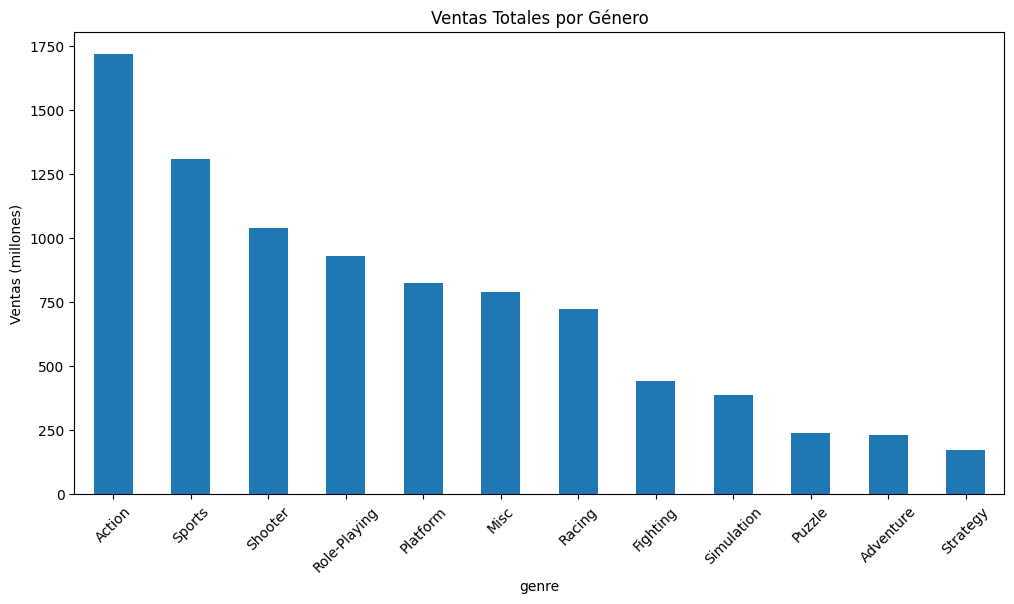

In [24]:
# Contar juegos por género
genre_counts = games['genre'].value_counts()
print("Distribución de juegos por género:")
print(genre_counts)
print(f"\nTotal de géneros únicos: {len(genre_counts)}")

# Análisis de ventas por género
genre_sales = games.groupby('genre').agg({
    'total_sales': ['sum', 'mean', 'count'],
    'name': 'count'
}).round(2)

# Renombrar columnas para claridad
genre_sales.columns = ['ventas_totales', 'ventas_promedio', 'num_juegos_sales', 'num_juegos']
genre_sales = genre_sales.sort_values('ventas_totales', ascending=False)

# Gráfico de barras para ventas totales
plt.figure(figsize=(12, 6))
genre_sales['ventas_totales'].plot(kind='bar')
plt.title('Ventas Totales por Género')
plt.ylabel('Ventas (millones)')
plt.xticks(rotation=45)
plt.show()

OBSERVACIONES:

El género más popular es “Action” , después le siguen  “Sports” y “Shooter” con altos niveles de ventas.  Los Géneros como “Strategy”, “Adventure” y “Puzzle” tienen tanto pocas ventas como menor número de lanzamientos. 
Se puede observar que el mercado de videojuegos está claramente dominado por los géneros de acción, deportes y disparos, que combinan popularidad y rentabilidad, mientras que los géneros más estratégicos o narrativos tienen una participación menor. Lo que muestra una clara preferencia del público por experiencias dinámicas y competitivas.


<h2>4. Crea un perfil de usuario para cada región<h2>

<h3>4.1 Análisis de Top 5 Plataformas por Región<h3>

=== TOP 5 PLATAFORMAS POR REGIÓN ===

Norteamérica (NA):
platform
X360    595.74
PS2     572.92
Wii     486.87
PS3     390.13
DS      380.31
Name: na_sales, dtype: float64

Europa (EU):
platform
PS2     332.63
PS3     327.21
X360    268.32
Wii     258.32
PS      212.39
Name: eu_sales, dtype: float64

Japón (JP):
platform
DS      175.02
PS      139.78
PS2     137.54
SNES    116.55
3DS     100.62
Name: jp_sales, dtype: float64


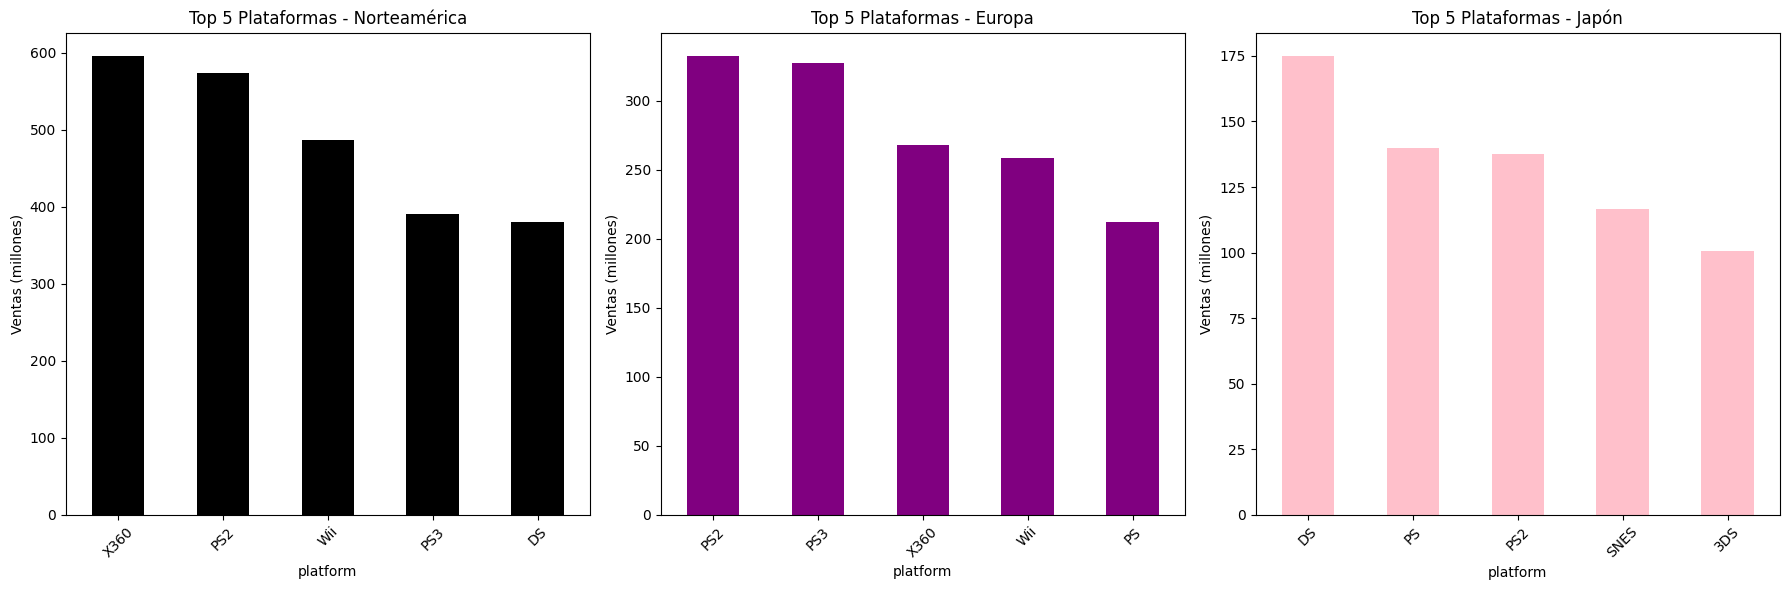

In [25]:
# Análisis de plataformas por región
na_platforms = games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_platforms = games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_platforms = games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

# Crear un DataFrame comparativo
platform_comparison = pd.DataFrame({
    'NA': na_platforms,
    'EU': eu_platforms, 
    'JP': jp_platforms
}).fillna(0)

# Tu código ya está bien, pero vamos a mejorarlo
print("=== TOP 5 PLATAFORMAS POR REGIÓN ===")
print("\nNorteamérica (NA):")
print(na_platforms)
print("\nEuropa (EU):")
print(eu_platforms)
print("\nJapón (JP):")
print(jp_platforms)

# Crear visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

na_platforms.plot(kind='bar', ax=axes[0], title='Top 5 Plataformas - Norteamérica', color='black')
axes[0].set_ylabel('Ventas (millones)')
axes[0].tick_params(axis='x', rotation=45)

eu_platforms.plot(kind='bar', ax=axes[1], title='Top 5 Plataformas - Europa', color='purple')
axes[1].set_ylabel('Ventas (millones)')
axes[1].tick_params(axis='x', rotation=45)

jp_platforms.plot(kind='bar', ax=axes[2], title='Top 5 Plataformas - Japón', color='pink')
axes[2].set_ylabel('Ventas (millones)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Análisis de géneros por región
na_genres = games.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_genres = games.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_genres = games.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)
# Análisis de ratings por región
rating_analysis = games.groupby('rating').agg({
    'na_sales': 'sum',
    'eu_sales': 'sum', 
    'jp_sales': 'sum'
}).sort_values('na_sales', ascending=False)


<h3>4.1.2 Análisis de Cuotas de Mercado por región<h3> 

In [26]:
# Calcular cuotas de mercado por región
total_na = games['na_sales'].sum()
total_eu = games['eu_sales'].sum()
total_jp = games['jp_sales'].sum()

print("=== CUOTAS DE MERCADO (%) ===")
print("\nNorteamérica:")
for platform, sales in na_platforms.items():
    percentage = (sales / total_na) * 100
    print(f"{platform}: {percentage:.1f}%")

print("\nEuropa:")
for platform, sales in eu_platforms.items():
    percentage = (sales / total_eu) * 100
    print(f"{platform}: {percentage:.1f}%")

print("\nJapón:")
for platform, sales in jp_platforms.items():
    percentage = (sales / total_jp) * 100
    print(f"{platform}: {percentage:.1f}%")
    

=== CUOTAS DE MERCADO (%) ===

Norteamérica:
X360: 13.7%
PS2: 13.2%
Wii: 11.2%
PS3: 9.0%
DS: 8.8%

Europa:
PS2: 13.9%
PS3: 13.6%
X360: 11.2%
Wii: 10.8%
PS: 8.9%

Japón:
DS: 13.6%
PS: 10.8%
PS2: 10.7%
SNES: 9.0%
3DS: 7.8%


OBSERVACIONES:

En Norteamérica predominan las consolas de Microsoft y Nintendo siendo Xbox (X360) la mas vendida. En cambio, en Europa destacan las consolas de Sony, como PlayStation (PS2 y PS3), las cuales lideran las ventas. En japón sobresalen las consolas portátiles y las de Nintendo, siendo la DS la más popular. Esto nos indica que cada región tiene gusstos diferentes y preferencias.

<h3>4.2 Análisis de Top 5 Plataformas por Género<h3>

=== TOP 5 GÉNEROS POR REGIÓN ===

Norteamérica (NA):
genre
Action      863.17
Sports      671.20
Shooter     584.83
Platform    444.44
Misc        399.57
Name: na_sales, dtype: float64

Europa (EU):
genre
Action     510.99
Sports     371.33
Shooter    314.52
Racing     234.49
Misc       210.60
Name: eu_sales, dtype: float64

Japón (JP):
genre
Role-Playing    353.39
Action          160.14
Sports          134.93
Platform        130.71
Misc            107.02
Name: jp_sales, dtype: float64


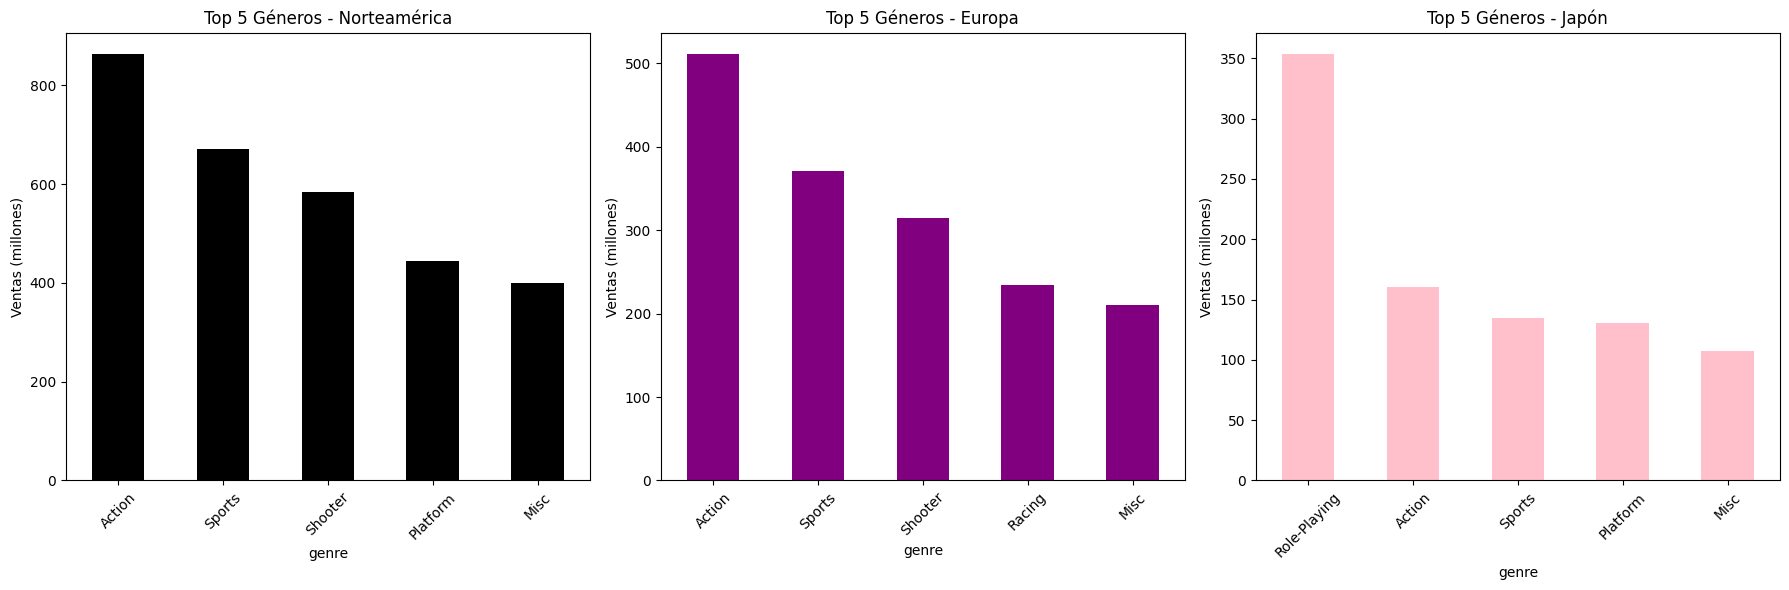

In [27]:
# Mostrar los top 5 géneros por región
print("=== TOP 5 GÉNEROS POR REGIÓN ===")
print("\nNorteamérica (NA):")
print(na_genres)
print("\nEuropa (EU):")
print(eu_genres)
print("\nJapón (JP):")
print(jp_genres)

# Crear visualización comparativa de géneros
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

na_genres.plot(kind='bar', ax=axes[0], title='Top 5 Géneros - Norteamérica', color='black')
axes[0].set_ylabel('Ventas (millones)')
axes[0].tick_params(axis='x', rotation=45)

eu_genres.plot(kind='bar', ax=axes[1], title='Top 5 Géneros - Europa', color='purple')
axes[1].set_ylabel('Ventas (millones)')
axes[1].tick_params(axis='x', rotation=45)

jp_genres.plot(kind='bar', ax=axes[2], title='Top 5 Géneros - Japón', color='pink')
axes[2].set_ylabel('Ventas (millones)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<h3>4.2.2 Análisis de Cuotas de Mercado por Género<h3>

In [28]:
# Calcular cuotas de mercado por género
print("=== CUOTAS DE MERCADO POR GÉNERO (%) ===")
print("\nNorteamérica:")
for genre, sales in na_genres.items():
    percentage = (sales / total_na) * 100
    print(f"{genre}: {percentage:.1f}%")

print("\nEuropa:")
for genre, sales in eu_genres.items():
    percentage = (sales / total_eu) * 100
    print(f"{genre}: {percentage:.1f}%")

print("\nJapón:")
for genre, sales in jp_genres.items():
    percentage = (sales / total_jp) * 100
    print(f"{genre}: {percentage:.1f}%")

=== CUOTAS DE MERCADO POR GÉNERO (%) ===

Norteamérica:
Action: 19.9%
Sports: 15.5%
Shooter: 13.5%
Platform: 10.2%
Misc: 9.2%

Europa:
Action: 21.3%
Sports: 15.5%
Shooter: 13.1%
Racing: 9.8%
Misc: 8.8%

Japón:
Role-Playing: 27.4%
Action: 12.4%
Sports: 10.5%
Platform: 10.1%
Misc: 8.3%


OBSERVACIONES:

Existen diferencias culturales en las preferencias de géneros. En Norteamérica y Europa, los juegos de acción y deportes son los mas populares, mientras que en Jacón destacan los de Role-Playing (RPG). Mientras que Occidente prefiere la acción, Japón valora más las historias y el desarrollo de personajes.

<h3>4.3 Análisis de Impacto de ESRB por Región<h3>

=== VENTAS POR CLASIFICACIÓN ESRB ===
         na_sales  eu_sales  jp_sales
rating                               
E         1274.24    703.87    197.96
Unknown   1225.84    609.65    836.74
T          747.60    421.79    150.70
M          742.89    480.00     63.58
E10+       345.50    183.35     40.20
K-A          2.56      0.27      1.46
EC           1.53      0.11      0.00
AO           1.26      0.61      0.00
RP           0.00      0.03      0.00


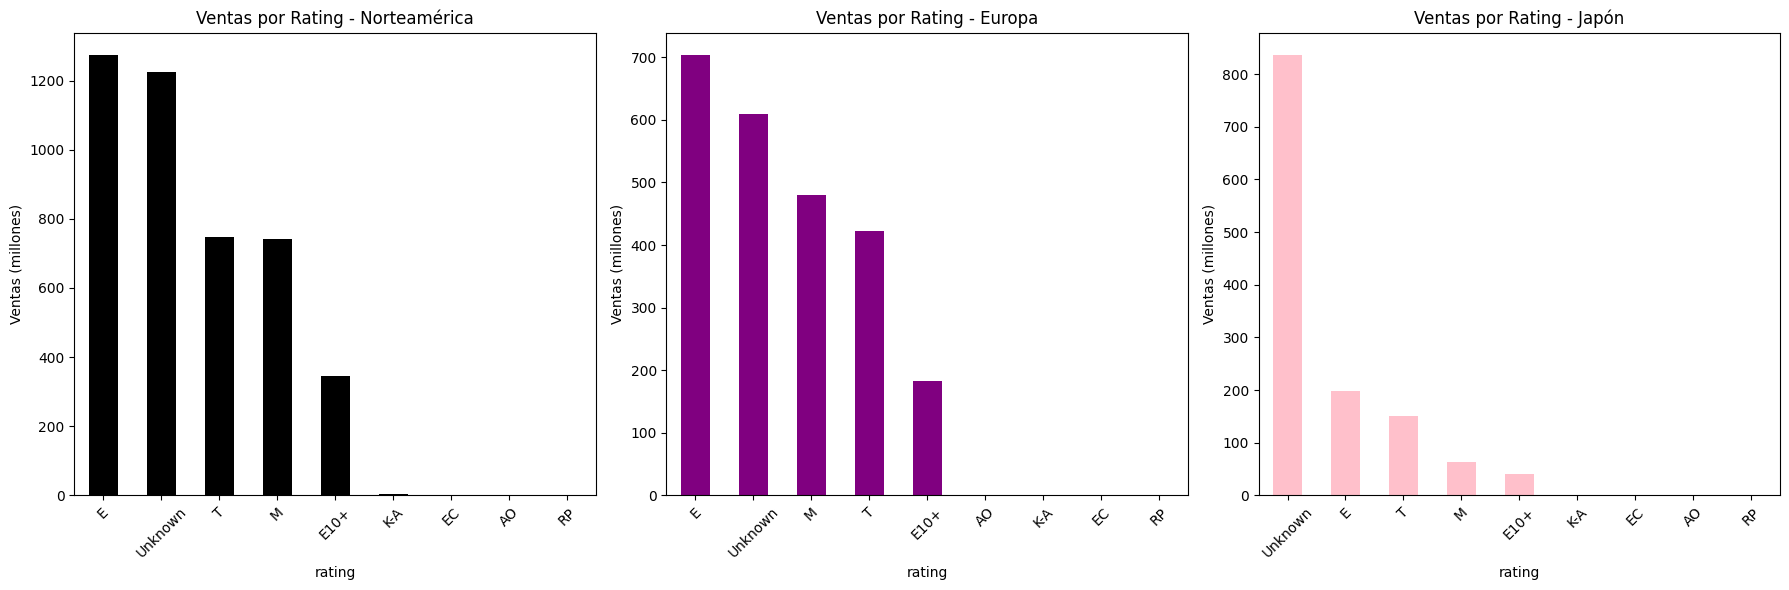

In [29]:
# Mostrar el análisis de ratings que ya calculaste
print("=== VENTAS POR CLASIFICACIÓN ESRB ===")
print(rating_analysis.sort_values('na_sales', ascending=False))

# Crear visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico para cada región
rating_analysis.sort_values('na_sales', ascending=False)['na_sales'].plot(
    kind='bar', ax=axes[0], title='Ventas por Rating - Norteamérica', color='black')
axes[0].set_ylabel('Ventas (millones)')
axes[0].tick_params(axis='x', rotation=45)

rating_analysis.sort_values('eu_sales', ascending=False)['eu_sales'].plot(
    kind='bar', ax=axes[1], title='Ventas por Rating - Europa', color='purple')
axes[1].set_ylabel('Ventas (millones)')
axes[1].tick_params(axis='x', rotation=45)

rating_analysis.sort_values('jp_sales', ascending=False)['jp_sales'].plot(
    kind='bar', ax=axes[2], title='Ventas por Rating - Japón', color='pink')
axes[2].set_ylabel('Ventas (millones)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


<h3>4.3.2 Análisis de Cuotas de Mercado por Rating<h3>

In [30]:
# Calcular cuotas de mercado por rating
print("=== CUOTAS DE MERCADO POR RATING (%) ===")
print("\nNorteamérica:")
for rating, row in rating_analysis.iterrows():
    percentage = (row['na_sales'] / total_na) * 100
    print(f"{rating}: {percentage:.1f}%")

print("\nEuropa:")
for rating, row in rating_analysis.iterrows():
    percentage = (row['eu_sales'] / total_eu) * 100
    print(f"{rating}: {percentage:.1f}%")

print("\nJapón:")
for rating, row in rating_analysis.iterrows():
    percentage = (row['jp_sales'] / total_jp) * 100
    print(f"{rating}: {percentage:.1f}%")

=== CUOTAS DE MERCADO POR RATING (%) ===

Norteamérica:
E: 29.4%
Unknown: 28.2%
T: 17.2%
M: 17.1%
E10+: 8.0%
K-A: 0.1%
EC: 0.0%
AO: 0.0%
RP: 0.0%

Europa:
E: 29.3%
Unknown: 25.4%
T: 17.6%
M: 20.0%
E10+: 7.6%
K-A: 0.0%
EC: 0.0%
AO: 0.0%
RP: 0.0%

Japón:
E: 15.3%
Unknown: 64.8%
T: 11.7%
M: 4.9%
E10+: 3.1%
K-A: 0.1%
EC: 0.0%
AO: 0.0%
RP: 0.0%


OBSERVACIONES:


Tenemos diferencias culturales en las tres regiones. Norteamérica y Europa tienen patrones similares. Por un lado, Europa es más liberal en la compra de contenido maduro y viento, Norteamérica es más estricta culturalmente.  En Japón en cambio compra consolas con contenido totalmente distinto ya que la mayoría de las ventas se concentran en juegos con clasificación desconocida, y las demás categorías tienen mucha menos participación. 



<h2>5. Prueba de hipótesis:<h2>

<h3> Hipótesis 1: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.<h3>  

In [31]:
# Paso 1: Crear las series de datos sin valores nulos
xone_scores = games[(games['platform'] == 'XOne') & (games['user_score'].notna())]['user_score']
pc_scores = games[(games['platform'] == 'PC') & (games['user_score'].notna())]['user_score']

# Paso 2: Prueba de Levene para igualdad de varianzas
levene_test = stats.levene(xone_scores, pc_scores)
print("Prueba de Levene:", levene_test)

# Paso 3: Prueba T de dos muestras independientes
if levene_test.pvalue < 0.05:
    results = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)
else:
    results = stats.ttest_ind(xone_scores, pc_scores, equal_var=True)

print("Prueba T:", results)

# Paso 4: Conclusión
alpha = 0.05
if results.pvalue < alpha:
    print("Rechazamos H₀: Las calificaciones promedio SON diferentes entre Xbox One y PC.")
else:
    print("No se rechaza H₁: Las calificaciones promedio NO son significativamente diferentes entre Xbox One y PC.")


Prueba de Levene: LeveneResult(statistic=1.1706180824505048, pvalue=0.2795532372785057)
Prueba T: Ttest_indResult(statistic=-4.38289526334195, pvalue=1.3037979620149106e-05)
Rechazamos H₀: Las calificaciones promedio SON diferentes entre Xbox One y PC.


CONCLUSION: SE RECHAZA LA HIPOTESIS NULA

La prueba de Levene muestra que las varianzas son iguales (p = 0.28 > 0.05). Sin embargo, la prueba t indica una diferencia significativa entre las medias (p < 0.05). Por lo tanto, se concluye que las calificaciones promedio sí son significativamente diferentes entre Xbox One y PC. 

<h3> Hipótesis 2: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.<h3>  

In [32]:
# Preparación de los datos
action_scores = games[(games['genre'] == 'Action') & (games['user_score'].notna())]['user_score']
sports_scores = games[(games['genre'] == 'Sports') & (games['user_score'].notna())]['user_score']

# Nivel de significancia
alpha = 0.05

# Prueba de Levene para igualdad de varianzas
levene_stat, levene_p = stats.levene(action_scores, sports_scores)

# Elegir tipo de t-test según Levene
equal_var = True if levene_p > alpha else False

# Prueba t de muestras independientes
t_stat, p_val = stats.ttest_ind(action_scores, sports_scores, equal_var=equal_var)

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_val:.4f}")
print(f"Igualdad de varianzas (Levene p): {levene_p:.4f}")

if p_val < alpha:
    print("Rechazamos H0: Las calificaciones promedio SON DIFERENTES entre Action y Sports.")
else:
    print("No se rechaza H0: Las calificaciones promedio NO SON significativamente diferentes entre Action y Sports.")


Estadístico t: 1.7894
Valor p: 0.0737
Igualdad de varianzas (Levene p): 0.0001
No se rechaza H0: Las calificaciones promedio NO SON significativamente diferentes entre Action y Sports.


CONCLUSION: NO SE RECHAZA LA HIPOTESIS NULA

El valor p es mayor que 0.05, por lo tanto, no se rechaza la hipótesis nula (H0). Esto indica que no existen diferencias estadísticamente significativas en las calificaciones promedio entre los géneros Action y Sports; es decir, ambos géneros tienen calificaciones similares.


<h2>CONCLUSIÓN FINAL DEL ANÁLISIS<h2>


El análisis de los datos históricos de videojuegos hasta 2016 permitió identificar los factores que influyen en el éxito comercial y en las tendencias del mercado. Se observó que las plataformas tienen un ciclo de vida promedio de 9 a 12 años, y para Para la tienda en línea Ice las oportunidades más rentables y prometedoras en 2017 serán PS4, Xbox One y las plataformas digitales. Las ventas globales dependen en gran medida de unos pocos títulos exitosos, especialmente de franquicias como Grand Theft Auto, Call of Duty y Mario Kart, y los juegos multiplataforma alcanzan mayores ventas. Las reseñas de críticos influyen más que las de los jugadores en el rendimiento comercial. En cuanto a géneros, predominan Action, Sports y Shooter, reflejando la preferencia del público por experiencias dinámicas. Además, existen marcadas diferencias regionales: Norteamérica y Europa comparten gustos similares centrados en acción y deportes, mientras que Japón prefiere los juegos de rol y portátiles. Finalmente, las pruebas estadísticas muestran que las calificaciones promedio difieren significativamente entre Xbox One y PC, pero no entre los géneros Action y Sports.